In [349]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

In [350]:
from src.models.train_model.train_model import *

In [374]:
def get_onehot_columns(df,cols,n_mimo):
    from src.models.feature_selector import get_index_dictionary
    
    dic_i = get_index_dictionary(df, n_mimo)
    unique_values_dict = {col: df[col].unique().tolist() for col in cols}
    #print(dic_i)
    g = []
    for col_name in unique_values_dict:
        list_value = unique_values_dict[col_name]
        for col in dic_i[col_name]:
            for value in list_value:
                g.append(f"{col}_{value}")
    return g

def add_col(df,all_col_name):
    new_col_names = [col for col in all_col_name if not col in df.columns]
    df_temp = pd.DataFrame(np.zeros((len(df), len(new_col_names))), columns=new_col_names)
    dfn = pd.concat([df, df_temp], axis=1)
    dfn.index = df.index
    return dfn

In [375]:
def train_model(df_train, n_mimo, save_model=False, save_model_folder=None,all_col = []):

    logger.info(f"Train model: Some features have been dropped successfully")

    feature_selector = Feature_selector(df_train, target="generation")
    Xs_train, ys_train, name_code_df, dic_col = feature_selector.get_X_and_y(n_mimo=n_mimo)
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=2000, max_depth=7, learning_rate=0.1)
    
    Xs_train = add_col(Xs_train,all_col)
    Xs_train = Xs_train[sorted(Xs_train.columns)]
    #(print(x) for x in Xs_train.columns)
    model.fit(Xs_train, ys_train)
    logger.info(f"Model has been trained successfully")
    
    ys_pred = model.predict(Xs_train)

    y_pred = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_train)
    rmse_error_train = compute_relative_rmse(y_pred, y_train)
    thresh_error_train = compute_threshold_error(y_pred, y_train)
    logger.info(f"Train rmse error: {rmse_error_train:0.2f}%")
    logger.info(f"Train threshold error: {thresh_error_train:0.2f}%")

    return model

    if save_model and save_model_folder is not None:
        for filename in os.listdir(save_model_folder):
            os.remove(os.path.join(save_model_folder, filename))

        dump(model, f"{save_model_folder}/model.joblib")


In [385]:
def test_model(model, df_test, n_mimo,all_col = []):

    logger.info(f"Test model: Some features have been dropped successfully")
    feature_selector = Feature_selector(df_test, target="generation")
    Xs_test, ys_test, name_code_df, dic_col = feature_selector.get_X_and_y(n_mimo=n_mimo)
    Xs_test = add_col(Xs_test,all_col)
    Xs_test = Xs_test[model.feature_names_in_]
    Xs_test = Xs_test[sorted(Xs_test.columns)]
    #print(Xs_test.columns)
    ys_pred = model.predict(Xs_test)
    y_pred = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_test)
    
    rmse_error_test = compute_relative_rmse(y_pred, y_test)
    thresh_error_test = compute_threshold_error(y_pred, y_test)
    logger.info(f"test rmse error: {rmse_error_test:0.2f}%")
    logger.info(f"test threshold error: {thresh_error_test:0.2f}%")
    
    return y_pred

In [ ]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

add_is_test_column(df)
save_model = True
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")
write_predictions = False
n_mimo = 4

train_test_ds = Data_selector(Data_selector(df).select_peaks(goodness=3))
train_df = train_test_ds.select_train_test(is_test=False)
test_df = train_test_ds.select_train_test(is_test=True)


base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                     "forecast", "status", "season", "datetime", "generation_with_24_delay"]

base_feature_selector = Feature_selector(df, target="generation")
base_feature_selector.select(features_to_select=base_features)
df_all = base_feature_selector.df.copy()

base_feature_selector = Feature_selector(train_df, target="generation")
base_feature_selector.select(features_to_select=base_features)
df_train = base_feature_selector.df.copy()

base_feature_selector = Feature_selector(test_df, target="generation")
base_feature_selector.select(features_to_select=base_features)
df_test = base_feature_selector.df.copy()

all_col = get_onehot_columns(df=df_all,cols=["name", "code","value","status","season"],n_mimo=n_mimo)

In [ ]:
b = ['0_حافظ', '0_سبلان', '0_سیکل ترکیبی ارومیه', '0_سیکل ترکیبی شیروان',
       '0_سیکل ترکیبی یزد', '0_شهدای پیروز - بهبهان', '0_عسلویه', '0_پرند',
       '10', '12', '13', '14', '15', '16_P', '17', '18_SO', '19_spring',
       '19_summer', '19_winter', '1_G12', '1_G13', '1_G14', '1_G15', '1_G16',
       '1_S1', '1_S2', '2', '20', '22', '23', '24', '25', '26_P', '27',
       '28_SO', '29_spring', '29_summer', '29_winter', '3', '30', '32', '33',
       '34', '35', '36_P', '37', '38_SO', '39_spring', '39_summer',
       '39_winter', '4', '40', '5', '6_P', '7', '8_SO', '9_spring', '9_summer',
       '9_winter']
c = ['0_جنوب اصفهان - چهلستون', '0_حافظ', '0_سبلان', '0_سیکل ترکیبی ارومیه',
       '0_سیکل ترکیبی شیروان', '0_سیکل ترکیبی یزد', '0_شهدای پیروز - بهبهان',
       '0_عسلویه', '0_پرند', '10', '12', '13', '14', '15', '16_M', '16_P',
       '17', '18_LF1', '18_SO', '19_fall', '19_spring', '19_summer',
       '19_winter', '1_G11', '1_G12', '1_G13', '1_G14', '1_G15', '1_G16',
       '1_S1', '1_S2', '2', '20', '22', '23', '24', '25', '26_M', '26_P', '27',
       '28_LF1', '28_SO', '29_fall', '29_spring', '29_summer', '29_winter',
       '3', '30', '32', '33', '34', '35', '36_M', '36_P', '37', '38_LF1',
       '38_SO', '39_fall', '39_spring', '39_summer', '39_winter', '4', '40',
       '5', '6_M', '6_P', '7', '8_LF1', '8_SO', '9_fall', '9_spring',
       '9_summer', '9_winter']
_=all_col


In [ ]:
print("train - test",np.array([eb for eb in b if not eb in c]))
print("test - train",np.array([ec for ec in c if not ec in b]))
print("all_col - train",np.array([el for el in all_col if not el in b]))
print("all_col - test",np.array([el for el in all_col if not el in c]))


train - test []
test - train ['0_جنوب اصفهان - چهلستون' '16_M' '18_LF1' '19_fall' '1_G11' '26_M'
 '28_LF1' '29_fall' '36_M' '38_LF1' '39_fall' '6_M' '8_LF1' '9_fall']
all_col - train ['0_جنوب اصفهان - چهلستون' '1_G11' '1_S3' '6_M' '6_L' '16_M' '16_L' '26_M'
 '26_L' '36_M' '36_L' '8_LF1' '8_R' '8_FA' '8_PM' '8_FP' '8_LA' '8_FO'
 '8_LG3' '8_LG5' '8_PA' '8_PO' '8_RLF1' '8_FQ' '8_LQ' '8_LP' '8_FG3'
 '8_FG5' '8_LD' '8_RLG5' '8_RLQ' '8_LW' '8_FG1' '8_ZLF1' '8_ZFO' '8_ZLA'
 '8_ZSO' '8_ZFG1' '8_ZLP' '8_ZPM' '8_ZFP' '8_ZLD' '8_ZLQ' '8_RLG3' '8_RLP'
 '8_LG1' '8_ZLG3' '8_FW' '8_PD' '8_ZD IN' '8_ZFA' '8_ZLG1' '18_LF1' '18_R'
 '18_FA' '18_PM' '18_FP' '18_LA' '18_FO' '18_LG3' '18_LG5' '18_PA' '18_PO'
 '18_RLF1' '18_FQ' '18_LQ' '18_LP' '18_FG3' '18_FG5' '18_LD' '18_RLG5'
 '18_RLQ' '18_LW' '18_FG1' '18_ZLF1' '18_ZFO' '18_ZLA' '18_ZSO' '18_ZFG1'
 '18_ZLP' '18_ZPM' '18_ZFP' '18_ZLD' '18_ZLQ' '18_RLG3' '18_RLP' '18_LG1'
 '18_ZLG3' '18_FW' '18_PD' '18_ZD IN' '18_ZFA' '18_ZLG1' '28_LF1' '28_R'
 '28_FA' '28

In [383]:
models = train_model(df_train, n_mimo, save_model, save_model_folder,all_col)

2025-09-28 16:04:09 - train_model - INFO - Train model: Some features have been dropped successfully
2025-09-28 16:04:51 - train_model - INFO - Model has been trained successfully
2025-09-28 16:04:53 - train_model - INFO - Train rmse error: 0.23%
2025-09-28 16:04:53 - train_model - INFO - Train threshold error: 0.01%


In [386]:
#models = load_model(save_model_folder)
test_model(models, df_test, n_mimo,all_col)

2025-09-28 16:05:22 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-28 16:05:24 - train_model - INFO - test rmse error: 2.09%
2025-09-28 16:05:24 - train_model - INFO - test threshold error: 0.39%


array([126.66812134, 125.14575577, 123.77976735, ..., 115.97714233,
       115.21923065, 117.30961609])

In [387]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [388]:
def change_df_rows(df,label):
    boolean_array = (label == 3).to_numpy()
    if not boolean_array[-1]:
        return df
    false_indices = np.where(~boolean_array)[0]
    least_false_index = false_indices[-1] if false_indices.size > 0 else None
    boolean_array[least_false_index:] = False
    return df[boolean_array]

In [430]:
def predict_sarimax(df,time,name,code,base_features,window,first_time,all_col):

    time3 = time
    time1 = time - np.timedelta64(window,"D")
    time2 = time + np.timedelta64(1,"D")
    time1 = max(time1,first_time)
    
    dff = df[(df["name"] == name) & (df["code"] == code)]
    times = pd.to_datetime(dff["datetime"])
    df_name_code_time = dff[(time1 <= times) & (times < time2)]

    base_feature_selector = Feature_selector(df_name_code_time, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_base = base_feature_selector.df.copy()

    dates = pd.to_datetime(df_name_code_time["datetime"]).to_numpy()
    mask_test = (time3 <= dates)
    df_base_train = df_base[~mask_test]
    label = df_name_code_time["is_good_peak"]
    df_base_train = change_df_rows(df_base_train,label[~mask_test])
    
    model = train_model(df_base_train, n_mimo,all_col=all_col)
    y_pred = test_model(model, df_base, n_mimo,all_col=all_col)
    y_act  = df_base["generation"]
    
    
    logger.info("y_pred generated")
    
    cols = [
    'temperature',
    'humidity',
    'dew',
    'surface_pressure',
    'forecast',
    'generation_with_24_delay']
    df_io = pd.DataFrame({col:df_name_code_time[col].to_numpy() for col in cols}, index=dates)
    df_io = df_io.asfreq('h')
    df_io["value"] = y_pred
    
    df_io.loc[np.array(label==3),"value"] = np.array(y_act)[np.array(label==3)]
    
    mask_test = (time3 <= df_io.index)
    train = df_io[~mask_test]
    test = df_io[mask_test]

    # تعریف پارامترهای SARIMA
    # SARIMA(p, d, q)(P, D, Q, s)
    p, d, q = 2, 2, 2            # پارامترهای غیر فصلی
    P, D, Q, s = 1, 1, 1, 24   # پارامترهای فصلی (s=12 برای داده ماهانه)

    # آموزش مدل
    model = SARIMAX(train['value'],
                    order=(p, d, q),
                    exog=train[cols],
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    results = model.fit(disp=True, maxiter=1000, method='cg')
    logger.info("Sarimax trained")

    # پیش‌بینی
    forecast_steps = len(test)
    forecast = results.get_forecast(steps=forecast_steps,exog=test[cols])
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    # محاسبه معیارهای ارزیابی
    
    mae = mean_absolute_error(test['value'], forecast_mean)
    mse = mean_squared_error(test['value'], forecast_mean)
    rmse = np.sqrt(mse)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    logger.info("finished")

    return forecast_mean,np.array(y_act)[-24:],test['value'],y_pred,label[mask_test]

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

first_time = np.datetime64("2021-03-24 12:00:00")
window_time = 10

name = "پرند"
code = "G11"
base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                    "forecast", "status", "season", "datetime", "generation_with_24_delay"]
model = models

In [431]:
def get_err(y_pred,y_act,is_test_data):
    if is_test_data.any():
        err = (y_pred - y_act)
        peak_err = err[np.array(is_test_data)]
        t = np.count_nonzero(is_test_data)
        return (np.array(peak_err)**2).mean(),t
    else:
        return 0,0

In [432]:
start_date = pd.Timestamp('2023-06-20')
end_date = pd.Timestamp('2023-06-20')
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
b = []
for time in date_range:
    y_pred,y_act,y_tra,y_mod,label = predict_sarimax(df,time,name,code,base_features,window_time,first_time,all_col)
    print(time,get_err(y_pred,y_act,label>=3))
    b.append((time,get_err(y_pred,y_act,label>=3)[0]))

2025-09-28 17:27:35 - train_model - INFO - Train model: Some features have been dropped successfully
2025-09-28 17:27:39 - train_model - INFO - Model has been trained successfully
2025-09-28 17:27:39 - train_model - INFO - Train rmse error: 0.00%
2025-09-28 17:27:39 - train_model - INFO - Train threshold error: 0.00%
2025-09-28 17:27:39 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-28 17:27:39 - train_model - INFO - test rmse error: 1.33%
2025-09-28 17:27:39 - train_model - INFO - test threshold error: 0.07%
2025-09-28 17:27:39 - train_model - INFO - y_pred generated


KeyboardInterrupt: 

In [424]:
y_pred = np.array(y_pred)
y_actt = y_act[-24:]
y_modd = np.array(y_mod)[-24:]
y_traa = np.array(y_tra)

In [425]:
((y_pred - y_actt)**2)[np.array(label==3)].mean()

13.256338635555961

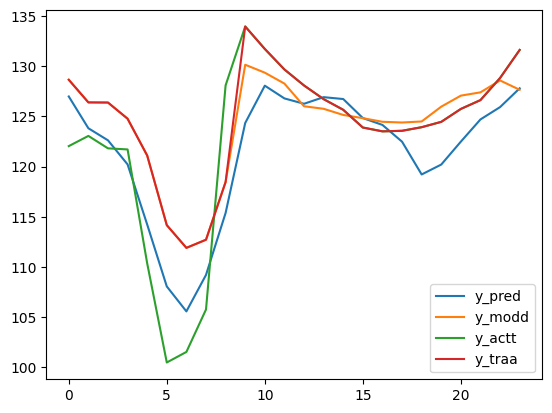

In [426]:
import matplotlib.pyplot as plt
plt.plot(y_pred,label="y_pred")
plt.plot(y_modd,label="y_modd")
plt.plot(y_actt,label="y_actt")
plt.plot(y_traa,label="y_traa")
plt.legend()
plt.show()